In [1]:

!pip install -q datasets pandas scikit-learn transformers accelerate torch


In [2]:
from datasets import load_dataset

dataset = load_dataset(
    "Hello-SimpleAI/HC3",
    "default",
    revision="refs/convert/parquet"
)

print(dataset)

all/train/0000.parquet: reconstructing file:   0%|          |  0.00B / 39.3MB            

all/train/0000.parquet: downloading bytes:           |  0.00B            

finance/train/0000.parquet: reconstructing file:   0%|          |  0.00B / 5.18MB            

finance/train/0000.parquet: downloading bytes:           |  0.00B            

medicine/train/0000.parquet: reconstructing file:   0%|          |  0.00B / 1.40MB            

...

reddit_eli5/train/0000.parquet: downloading bytes:           |  0.00B            

wiki_csai/train/0000.parquet: reconstructing file:   0%|          |  0.00B / 1.08MB            

wiki_csai/train/0000.parquet: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'question', 'human_answers', 'chatgpt_answers', 'source'],
        num_rows: 48644
    })
})


In [3]:

print("Available splits:", dataset.keys())
print("Columns:", dataset["train"].column_names)

sample = dataset["train"][0]

print("\nQuestion:")
print(sample["question"])

print("\nHuman answers:")
print(sample["human_answers"])

print("\nChatGPT answers:")
print(sample["chatgpt_answers"])


Available splits: dict_keys(['train'])
Columns: ['id', 'question', 'human_answers', 'chatgpt_answers', 'source']

Question:
Why is every book I hear about a " NY Times # 1 Best Seller " ? ELI5 : Why is every book I hear about a " NY Times # 1 Best Seller " ? Should n't there only be one " # 1 " best seller ? Please explain like I'm five.

Human answers:
['Basically there are many categories of " Best Seller " . Replace " Best Seller " by something like " Oscars " and every " best seller " book is basically an " oscar - winning " book . May not have won the " Best film " , but even if you won the best director or best script , you \'re still an " oscar - winning " film . Same thing for best sellers . Also , IIRC the rankings change every week or something like that . Some you might not be best seller one week , but you may be the next week . I guess even if you do n\'t stay there for long , you still achieved the status . Hence , # 1 best seller .', "If you 're hearing about it , it 's 

In [4]:

import pandas as pd

rows = []

for example in dataset["train"]:
    question_id = example["id"]

    for answer in example["human_answers"]:
        if isinstance(answer, str) and answer.strip():
            rows.append({
                "question_id": question_id,
                "text": answer.strip(),
                "label": 0
            })

    for answer in example["chatgpt_answers"]:
        if isinstance(answer, str) and answer.strip():
            rows.append({
                "question_id": question_id,
                "text": answer.strip(),
                "label": 1
            })

df = pd.DataFrame(rows)

print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (170862, 3)
  question_id                                               text  label
0           0  Basically there are many categories of " Best ...      0
1           0  If you 're hearing about it , it 's because it...      0
2           0  One reason is lots of catagories . However , h...      0
3           0  There are many different best seller lists tha...      1
4           1  salt is good for not dying in car crashes and ...      0


In [26]:
from google.colab import files
files.download("hc3_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:

df = df.dropna(subset=["text"])
df["text"] = df["text"].astype(str).str.strip()

df = df[df["text"] != ""]
df = df.drop_duplicates(subset=["text"])
df = df.reset_index(drop=True)

print("Samples after cleaning:", len(df))
print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nExample human text:")
print(df[df["label"] == 0]["text"].iloc[0][:500])

print("\nExample AI text:")
print(df[df["label"] == 1]["text"].iloc[0][:500])


Samples after cleaning: 79331

Label distribution:
label
0    53086
1    26245
Name: count, dtype: int64

Example human text:
Basically there are many categories of " Best Seller " . Replace " Best Seller " by something like " Oscars " and every " best seller " book is basically an " oscar - winning " book . May not have won the " Best film " , but even if you won the best director or best script , you 're still an " oscar - winning " film . Same thing for best sellers . Also , IIRC the rankings change every week or something like that . Some you might not be best seller one week , but you may be the next week . I gues

Example AI text:
There are many different best seller lists that are published by various organizations, and the New York Times is just one of them. The New York Times best seller list is a weekly list that ranks the best-selling books in the United States based on sales data from a number of different retailers. The list is published in the New York Times newspaper and

In [6]:

df.to_csv("hc3_cleaned.csv", index=False)

print("Saved hc3_cleaned.csv")


Saved hc3_cleaned.csv


Dataset shape: (79331, 3)

Class distribution:
label
Human-written    53086
AI-generated     26245
Name: count, dtype: int64

Text length statistics:
count    79331.000000
mean       147.761707
std        140.564027
min          1.000000
25%         59.000000
50%        121.000000
75%        195.000000
max       7904.000000
Name: word_count, dtype: float64


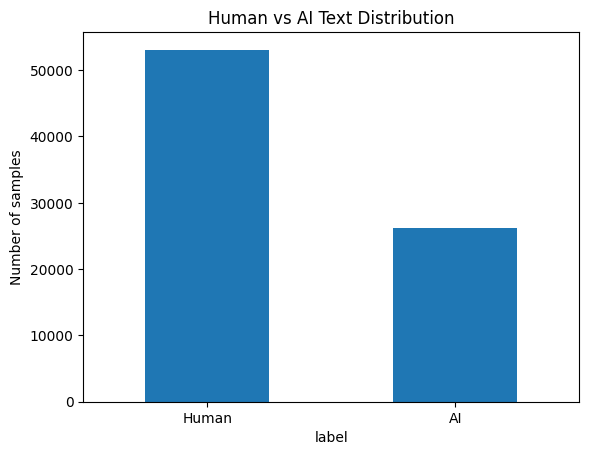

In [7]:

import matplotlib.pyplot as plt

print("Dataset shape:", df.shape)

print("\nClass distribution:")
print(df["label"].value_counts().rename({
    0: "Human-written",
    1: "AI-generated"
}))

df["word_count"] = df["text"].str.split().str.len()

print("\nText length statistics:")
print(df["word_count"].describe())

df["label"].value_counts().sort_index().plot(
    kind="bar",
    rot=0
)

plt.xticks([0, 1], ["Human", "AI"])
plt.ylabel("Number of samples")
plt.title("Human vs AI Text Distribution")
plt.show()


In [8]:

from sklearn.model_selection import GroupShuffleSplit

split1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, remaining_idx = next(
    split1.split(df, groups=df["question_id"])
)

train_df = df.iloc[train_idx].copy()
remaining_df = df.iloc[remaining_idx].copy()

split2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    split2.split(
        remaining_df,
        groups=remaining_df["question_id"]
    )
)

val_df = remaining_df.iloc[val_idx].copy()
test_df = remaining_df.iloc[test_idx].copy()

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

print("\nTraining labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(val_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())


Training samples: 55560
Validation samples: 11944
Test samples: 11827

Training labels:
label
0    37264
1    18296
Name: count, dtype: int64

Validation labels:
label
0    7968
1    3976
Name: count, dtype: int64

Test labels:
label
0    7854
1    3973
Name: count, dtype: int64


In [1]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    probabilities = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    probabilities = probabilities / probabilities.sum(axis=1, keepdims=True)

    try:
        auc = roc_auc_score(labels, probabilities[:, 1])
    except ValueError:
        auc = 0.0

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": auc
    }

In [2]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./ai_text_detector",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    weight_decay=0.01,
    save_total_limit=2,
    report_to="none",
    fp16=False
)

In [5]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, DataCollatorWithPadding
from datasets import Dataset

# 1. Load the cleaned data from disk
df = pd.read_csv("hc3_cleaned.csv")

# 2. Perform the train/validation split
split1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, remaining_idx = next(split1.split(df, groups=df["question_id"]))

train_df = df.iloc[train_idx].copy()
remaining_df = df.iloc[remaining_idx].copy()

split2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, _ = next(split2.split(remaining_df, groups=remaining_df["question_id"]))
val_df = remaining_df.iloc[val_idx].copy()

# 3. Initialize the model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained(
    "FacebookAI/xlm-roberta-base",
    num_labels=2
)
tokenizer = AutoTokenizer.from_pretrained("FacebookAI/xlm-roberta-base")

# 4. Convert to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df[["text", "label"]])
val_dataset = Dataset.from_pandas(val_df[["text", "label"]])

# 5. Tokenization
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 6. Initialize Trainer and Train
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/55473 [00:00<?, ? examples/s]

Map:   0%|          | 0/11895 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.028450,0.037095,0.993359,0.997931,0.981929,0.989865,0.999638
2,0.009081,0.025642,0.995712,0.987676,0.999491,0.993548,0.999972
3,0.001159,0.043968,0.995124,0.985696,0.999745,0.992671,0.999962


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=20805, training_loss=0.021294322733708466, metrics={'train_runtime': 5778.2192, 'train_samples_per_second': 28.801, 'train_steps_per_second': 3.601, 'total_flos': 1.094568918069672e+16, 'train_loss': 0.021294322733708466, 'epoch': 3.0})

In [7]:
from datasets import Dataset


split2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
_, test_idx = next(split2.split(remaining_df, groups=remaining_df["question_id"]))
test_df = remaining_df.iloc[test_idx].copy()

# 2. Convert to Hugging Face Dataset
test_dataset = Dataset.from_pandas(test_df[["text", "label"]])

# 3. Tokenize test dataset using the existing tokenizer
test_dataset = test_dataset.map(tokenize_function, batched=True)

# 4. Evaluate using the trainer
test_results = trainer.evaluate(test_dataset)

print("Test Results:")
for metric, value in test_results.items():
    print(f"{metric}: {value:.4f}")

Map:   0%|          | 0/11963 [00:00<?, ? examples/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Roc Auc
0.001159,0.026481,3,0.995486,0.987170,0.999236,0.993166,0.999961


Test Results:
eval_loss: 0.0265
eval_accuracy: 0.9955
eval_precision: 0.9872
eval_recall: 0.9992
eval_f1: 0.9932
eval_roc_auc: 1.0000


In [8]:
model_save_path = "./fine_tuned_ai_text_detector"

trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

print("Model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!


In [9]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "./fine_tuned_ai_text_detector"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def detect_ai_text(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=-1)[0]

    prediction = torch.argmax(probabilities).item()

    label = "AI-generated" if prediction == 1 else "Human-written"
    confidence = probabilities[prediction].item() * 100

    return {
        "prediction": label,
        "confidence": round(confidence, 2),
        "human_probability": round(probabilities[0].item() * 100, 2),
        "ai_probability": round(probabilities[1].item() * 100, 2)
    }

text = """
Artificial intelligence is transforming education by helping students
understand complex concepts, practice problem-solving, and receive
personalized feedback.
"""

print(detect_ai_text(text))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'prediction': 'Human-written', 'confidence': 99.95, 'human_probability': 99.95, 'ai_probability': 0.05}


In [10]:
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

print("Training metrics:")
print(trainer.state.log_history[-5:])

Training samples: 55473
Validation samples: 11895
Test samples: 11963
Training metrics:
[{'loss': 0.0010901821851730348, 'grad_norm': 6.541447510244325e-05, 'learning_rate': 7.748137466955059e-07, 'epoch': 2.883922134102379, 'step': 20000}, {'loss': 0.0011588635444641114, 'grad_norm': 7.259762787725776e-05, 'learning_rate': 2.941600576784427e-07, 'epoch': 2.9560201874549388, 'step': 20500}, {'eval_loss': 0.043967824429273605, 'eval_accuracy': 0.9951240016813787, 'eval_precision': 0.9856963613550815, 'eval_recall': 0.9997454823110206, 'eval_f1': 0.992671215567349, 'eval_roc_auc': 0.9999617872011022, 'eval_runtime': 104.1882, 'eval_samples_per_second': 114.168, 'eval_steps_per_second': 14.272, 'epoch': 3.0, 'step': 20805}, {'train_runtime': 5778.2192, 'train_samples_per_second': 28.801, 'train_steps_per_second': 3.601, 'total_flos': 1.094568918069672e+16, 'train_loss': 0.021294322733708466, 'epoch': 3.0, 'step': 20805}, {'eval_loss': 0.02648136578500271, 'eval_accuracy': 0.99548608208643

In [11]:
print("Training labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(val_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

Training labels:
label
0    37084
1    18389
Name: count, dtype: int64

Validation labels:
label
0    7966
1    3929
Name: count, dtype: int64

Test labels:
label
0    8036
1    3927
Name: count, dtype: int64


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

pred_output = trainer.predict(test_dataset)

y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=-1)

print(classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=["Human-written", "AI-generated"],
    digits=4,
    zero_division=0
))

print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

               precision    recall  f1-score   support

Human-written     0.9996    0.9937    0.9966      8036
 AI-generated     0.9872    0.9992    0.9932      3927

     accuracy                         0.9955     11963
    macro avg     0.9934    0.9964    0.9949     11963
 weighted avg     0.9955    0.9955    0.9955     11963

Confusion matrix:
[[7985   51]
 [   3 3924]]


In [13]:
import torch

THRESHOLD = 0.5

def detect_ai_text(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=-1)[0]

    ai_probability = probabilities[1].item()

    if ai_probability >= THRESHOLD:
        result = "AI-generated"
    else:
        result = "Not AI-generated"

    return result


text = """
Artificial intelligence is transforming education by helping
students understand complex concepts and solve problems.
"""

print(detect_ai_text(text))

Not AI-generated


In [14]:
test_paragraphs = [
    # 1. Informal personal writing
    """
    Yesterday I went to college a little late because my bus
    was delayed. I missed the first few minutes of class, but
    luckily my friend shared the notes with me. After college,
    we went to a nearby restaurant and had lunch together.
    """,

    # 2. Formal academic writing
    """
    Artificial intelligence has become an important area of
    research in recent years. Machine learning algorithms can
    identify patterns in large datasets and use these patterns
    to make predictions. These techniques are applied in
    healthcare, education, finance, and transportation.
    """,

    # 3. Personal opinion
    """
    In my opinion, online education is convenient, but it
    cannot completely replace classroom learning. Students
    can attend lectures from home, although some find it
    difficult to remain focused without direct interaction
    with teachers and classmates.
    """,

    # 4. Technical explanation
    """
    A database management system stores and organizes data
    so that applications can retrieve and update information
    efficiently. SQL is commonly used to query relational
    databases, create tables, and manage records.
    """,

    # 5. Casual conversational writing
    """
    I tried learning Python last month, but initially I found
    loops and functions confusing. After solving a few basic
    problems every day, things started making more sense.
    Practicing small programs helped me understand the concepts.
    """,

    # 6. Environmental topic
    """
    Plastic waste has become a serious environmental concern.
    Many plastic products are used for only a few minutes but
    remain in the environment for years. Reusing materials,
    recycling waste, and reducing unnecessary packaging can
    help limit plastic pollution.
    """,

    # 7. Student experience
    """
    Preparing for examinations is stressful when several
    subjects have assignments and deadlines at the same time.
    I usually make a list of topics and study the difficult
    ones first. Taking short breaks also helps me concentrate.
    """,

    # 8. Formal AI-style explanation
    """
    Cloud computing enables organizations to access computing
    resources over the internet without maintaining all the
    required infrastructure themselves. It provides flexible
    storage, scalable processing capacity, and services that
    can be adjusted according to changing workloads.
    """,

    # 9. Science explanation
    """
    Photosynthesis is the process through which green plants
    convert light energy into chemical energy. Plants use
    carbon dioxide and water to produce glucose and release
    oxygen. This process supports plant growth and contributes
    to the balance of gases in the atmosphere.
    """,

    # 10. Short passage
    """
    I enjoy playing cricket on weekends because it gives me
    an opportunity to exercise and spend time with friends.
    """,

    # 11. Software engineering
    """
    Software testing helps developers identify defects before
    an application is released. Unit tests examine individual
    components, while integration tests verify whether multiple
    components work together correctly. Automated testing can
    reduce repetitive manual work.
    """,

    # 12. Reflective writing
    """
    Sometimes progress feels slow even when we are putting
    in consistent effort. I have noticed that looking back
    at what I learned over the past few weeks helps me stay
    motivated. Small improvements eventually make a difference.
    """
]

for i, paragraph in enumerate(test_paragraphs, start=1):
    result = detect_ai_text(paragraph)
    print(f"Paragraph {i}: {result}")

Paragraph 1: Not AI-generated
Paragraph 2: AI-generated
Paragraph 3: Not AI-generated
Paragraph 4: Not AI-generated
Paragraph 5: Not AI-generated
Paragraph 6: AI-generated
Paragraph 7: Not AI-generated
Paragraph 8: AI-generated
Paragraph 9: AI-generated
Paragraph 10: Not AI-generated
Paragraph 11: Not AI-generated
Paragraph 12: Not AI-generated


In [16]:
import torch

def detect_ai_text_detailed(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=-1)[0]

    prediction = torch.argmax(probabilities).item()

    label = "AI-generated" if prediction == 1 else "Human-written"
    confidence = probabilities[prediction].item() * 100

    return {
        "prediction": label,
        "confidence": round(confidence, 2),
        "human_probability": round(probabilities[0].item() * 100, 2),
        "ai_probability": round(probabilities[1].item() * 100, 2)
    }

for i, paragraph in enumerate(test_paragraphs, start=1):
    result = detect_ai_text_detailed(paragraph)

    print(f"\nParagraph {i}")
    print("Prediction:", result["prediction"])
    print("Confidence:", result["confidence"], "%")
    print("Human probability:", result["human_probability"], "%")
    print("AI probability:", result["ai_probability"], "%")


Paragraph 1
Prediction: Human-written
Confidence: 100.0 %
Human probability: 100.0 %
AI probability: 0.0 %

Paragraph 2
Prediction: AI-generated
Confidence: 99.29 %
Human probability: 0.71 %
AI probability: 99.29 %

Paragraph 3
Prediction: Human-written
Confidence: 99.94 %
Human probability: 99.94 %
AI probability: 0.06 %

Paragraph 4
Prediction: Human-written
Confidence: 99.95 %
Human probability: 99.95 %
AI probability: 0.05 %

Paragraph 5
Prediction: Human-written
Confidence: 100.0 %
Human probability: 100.0 %
AI probability: 0.0 %

Paragraph 6
Prediction: AI-generated
Confidence: 99.99 %
Human probability: 0.01 %
AI probability: 99.99 %

Paragraph 7
Prediction: Human-written
Confidence: 100.0 %
Human probability: 100.0 %
AI probability: 0.0 %

Paragraph 8
Prediction: AI-generated
Confidence: 99.7 %
Human probability: 0.3 %
AI probability: 99.7 %

Paragraph 9
Prediction: AI-generated
Confidence: 99.99 %
Human probability: 0.01 %
AI probability: 99.99 %

Paragraph 10
Prediction: Hum

In [18]:
with open("/content/nasa_news_articles_for_testing.txt", "r", encoding="utf-8") as f:
    news_text = f.read()

result = detect_ai_text(news_text)
print(result)

Not AI-generated


In [23]:
text_input = '''Earth is the third planet from the Sun and the only known planet that supports life. It is often called the Blue Planet because approximately 71% of its surface is covered with water. Earth provides the essential resources needed for the survival of humans, animals, and plants, including air, water, food, and suitable environmental conditions. Its atmosphere protects living organisms from harmful solar radiation and helps maintain a temperature that supports life.
The Earth consists of several layers, including the crust, mantle, outer core, and inner core. The crust is the outermost layer on which we live. It contains continents, mountains, valleys, forests, and oceans. The mantle lies beneath the crust and consists of hot rock that moves slowly over long periods. The outer core is mainly composed of liquid iron and nickel, while the inner core is extremely hot and remains solid because of immense pressure. These internal layers play an important role in Earth's geological activity, including earthquakes, volcanic eruptions, and the movement of tectonic plates.
Water is one of the most important resources on Earth. Oceans, rivers, lakes, glaciers, and underground water sources support ecosystems and human activities. Water is essential for drinking, agriculture, industry, and the survival of living organisms. Although Earth contains a large amount of water, most of it is salt water found in oceans. Only a small percentage is freshwater available for human use, making water conservation an important responsibility.
Earth's atmosphere consists mainly of nitrogen and oxygen, along with smaller amounts of other gases. It enables humans and animals to breathe and helps regulate the planet's temperature. The natural greenhouse effect keeps Earth warm enough to support life. However, human activities such as burning fossil fuels, deforestation, and industrial pollution increase the concentration of greenhouse gases. This contributes to global warming and climate change, which can lead to rising temperatures, melting glaciers, changing rainfall patterns, and more frequent extreme weather events.
Biodiversity is another essential feature of Earth. The planet is home to millions of species of plants, animals, fungi, and microorganisms. Forests provide oxygen, absorb carbon dioxide, and offer habitats for wildlife. Oceans support marine organisms and help regulate the global climate. Every species plays a role in maintaining ecological balance. However, habitat destruction, pollution, overexploitation of natural resources, and climate change threaten biodiversity worldwide.
Human beings depend heavily on Earth's natural resources for survival and development. Agriculture provides food, forests supply timber, and minerals support industries and technological advancements. However, excessive consumption and unsustainable practices can damage the environment. Deforestation reduces wildlife habitats, plastic waste pollutes water bodies, and air pollution affects human health. These problems demonstrate the importance of responsible resource management.
Protecting Earth requires cooperation among individuals, communities, governments, and industries. People can contribute by planting trees, conserving water, reducing plastic usage, recycling waste, and using energy efficiently. Renewable energy sources such as solar and wind power can reduce dependence on fossil fuels. Governments and organizations can support environmental protection through sustainable policies, conservation programs, and public awareness campaigns. Education also plays a significant role in encouraging people to adopt environmentally friendly habits.
In conclusion, Earth is a remarkable planet that provides everything necessary for life. Its natural systems, diverse ecosystems, and abundant resources make it our most valuable home. However, environmental challenges threaten the balance that supports living organisms. Every individual has a responsibility to protect the planet and use its resources wisely. By adopting sustainable practices and working together, humanity can help preserve Earth's beauty and natural wealth for future generations. Protecting Earth is not merely a choice but a shared responsibility that determines the future of life on our planet.'''

result = detect_ai_text(text_input)
print(result)

AI-generated


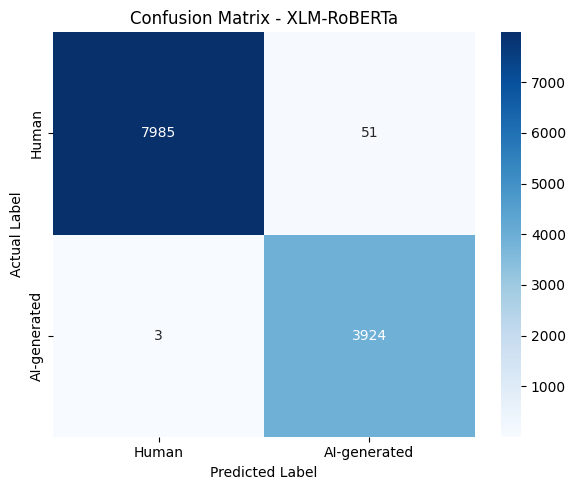

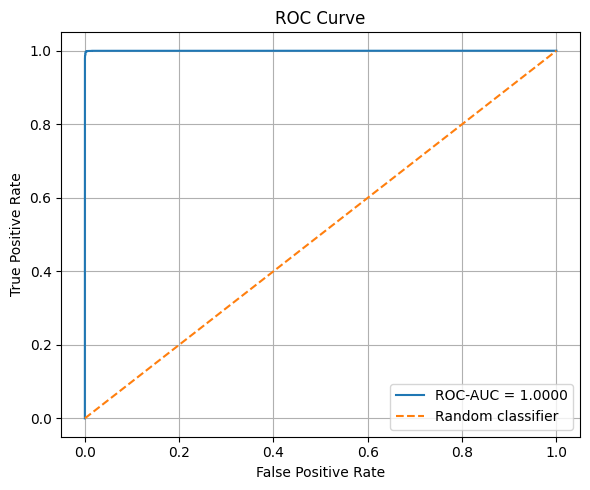

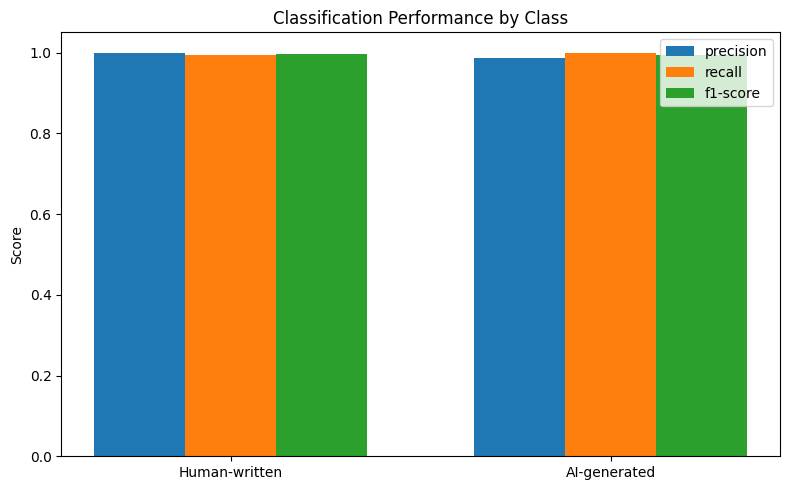

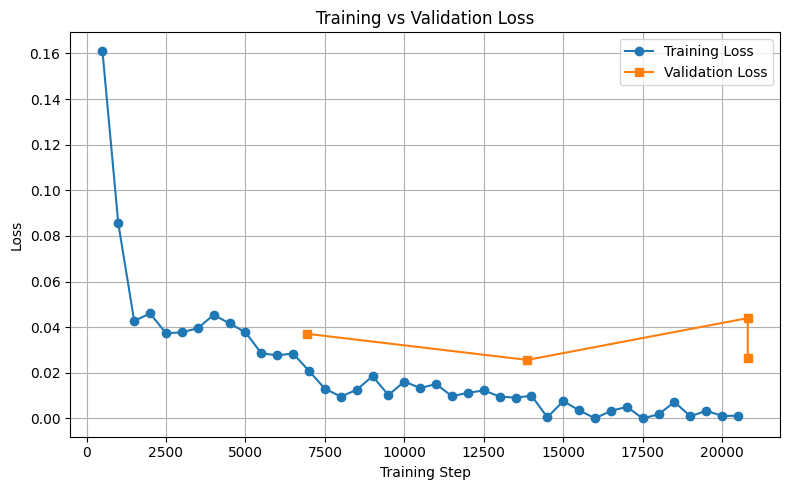

Test ROC-AUC: 1.0
               precision    recall  f1-score   support

Human-written       1.00      0.99      1.00      8036
 AI-generated       0.99      1.00      0.99      3927

     accuracy                           1.00     11963
    macro avg       0.99      1.00      0.99     11963
 weighted avg       1.00      1.00      1.00     11963



In [24]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    classification_report
)

# 1. Get predictions on the existing test dataset
pred_output = trainer.predict(test_dataset)

y_true = pred_output.label_ids
logits = pred_output.predictions

# Convert logits to probabilities using softmax
exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
probabilities = exp_logits / exp_logits.sum(axis=1, keepdims=True)

# Class 1 = AI-generated
ai_probabilities = probabilities[:, 1]
y_pred = np.argmax(logits, axis=1)

# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Human", "AI-generated"],
    yticklabels=["Human", "AI-generated"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - XLM-RoBERTa")
plt.tight_layout()
plt.show()

# 3. ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, ai_probabilities)
auc_score = roc_auc_score(y_true, ai_probabilities)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], "--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Precision, Recall, F1-score
report = classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=["Human-written", "AI-generated"],
    output_dict=True
)

metrics = ["precision", "recall", "f1-score"]
classes = ["Human-written", "AI-generated"]

x = np.arange(len(classes))
width = 0.24

plt.figure(figsize=(8, 5))
for i, metric in enumerate(metrics):
    values = [report[c][metric] for c in classes]
    plt.bar(x + (i - 1) * width, values, width, label=metric)

plt.xticks(x, classes)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Classification Performance by Class")
plt.legend()
plt.tight_layout()
plt.show()

# 5. Training Loss vs Validation Loss
history = trainer.state.log_history

train_logs = [
    item for item in history
    if "loss" in item and "eval_loss" not in item
]
eval_logs = [
    item for item in history
    if "eval_loss" in item
]

plt.figure(figsize=(8, 5))

if train_logs:
    plt.plot(
        [item["step"] for item in train_logs],
        [item["loss"] for item in train_logs],
        marker="o",
        label="Training Loss"
    )

if eval_logs:
    plt.plot(
        [item["step"] for item in eval_logs],
        [item["eval_loss"] for item in eval_logs],
        marker="s",
        label="Validation Loss"
    )

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Test ROC-AUC:", round(auc_score, 4))
print(classification_report(
    y_true, y_pred,
    target_names=["Human-written", "AI-generated"]
))
